# Ejercicio análisis time series
Para este ejercicio vas a trabajar con el histórico de valores en bolsa de una empresa que se dedica a vender muebles. Se pide
1. Importa los datos `df_furniture.csv`
2. Trata la fecha como texto. Crea una columna para el año, mes y dia, y a partir de esas columnas crea la de fecha, en formato datetime de pandas
3. ¿De qué fecha a qué fecha va el histórico?
4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?
5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es stationary?
6. Parece que hay una tendencia, pero no se aprecia bien con tanto pico en la serie. ¿Conoces algún método para representar mejor la tendencia?
7. Estaría bien visualizar todos los componentes de la serie temporal por separado
8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional
9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación. ¿Esto es bueno para los modelos?
10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?
11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Cargamos los datos

In [2]:
# Code
df_data = pd.read_csv (r'data\df_furniture.csv')

In [4]:
df_data.head()

,Month,furniture_price_adjusted
0,1992-01-01,2073.432724
1,1992-02-01,2114.485812
2,1992-03-01,2260.570891
3,1992-04-01,2255.103236
4,1992-05-01,2331.414618


## 2. Tratar la fecha como texto e interpretar (parse)

In [3]:
# Code
# La pasamos a tipo datetime. Vale. No pedía esto. Aunque es más fácil así
df_data ['Month'] = pd.to_datetime(df_data['Month'])



In [13]:
df_data.dtypes

Month                       datetime64[ns]
furniture_price_adjusted           float64
dtype: object

## 3. ¿De qué fecha a qué fecha va el histórico?

In [4]:
# Code
print (f"Desde: {df_data['Month'].min()}")
print (f"Hasta: {df_data['Month'].max()}")
      

Desde: 1992-01-01 00:00:00
Hasta: 2019-07-01 00:00:00


## 4. ¿Cómo es la serie temporal? ¿Tiene tendencia? ¿Aprecias alguna estacionalidad?

In [22]:
df_data.columns

Index(['Month', 'furniture_price_adjusted'], dtype='object')

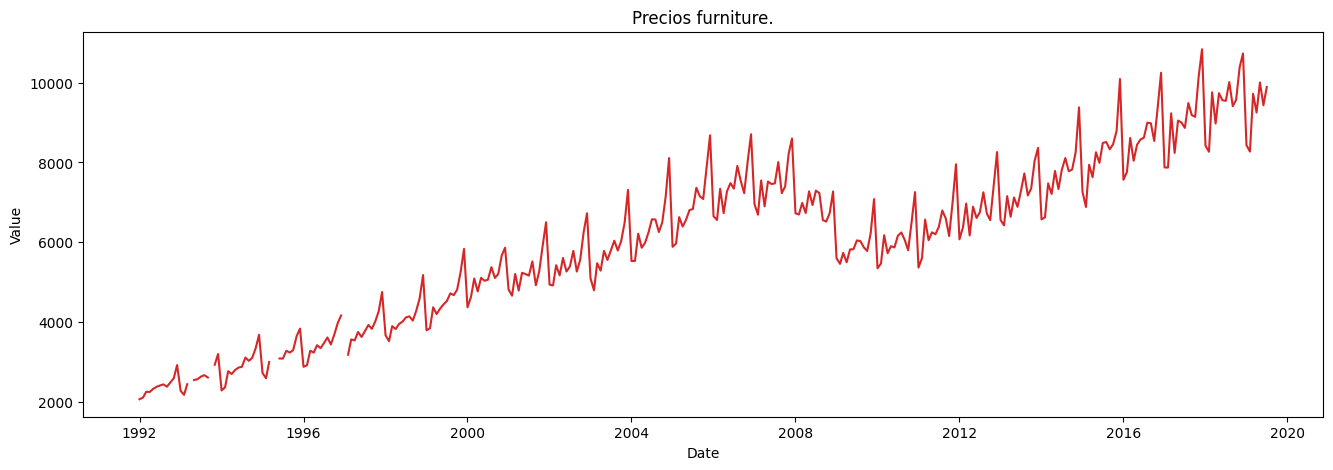

In [23]:
# Code. Un plot
def plot_df(df, x, y, title="", xlabel='Date', ylabel='Value', dpi=100):
    plt.figure(figsize=(16,5), dpi=dpi)
    plt.plot(x, y, color='tab:red')
    plt.gca().set(title=title, xlabel=xlabel, ylabel=ylabel)
    plt.show()

plot_df(df_data, x=df_data['Month'], y=df_data['furniture_price_adjusted'], title='Precios furniture.') 


In [ ]:
# Tiene tendencia puesto que sube y también parece que tiene estacionalidad porque hay patrones parecidos
# que tienden a repetirse periódicamente.
# También se aprecia que faltan datos entre 1992 y 1997-8


In [25]:
df_data[~df_data['furniture_price_adjusted'].notna()]
#Ah, pues no

,Month,furniture_price_adjusted


In [5]:
df_data.isna().sum()

Month                       5
furniture_price_adjusted    0
dtype: int64

In [ ]:
# Sí que había NULOS en fecha. Y además faltan fechas. Habría que sacar los primeros de cada mes y comprobar 
# que están todos (un len de eso y otro len de las fechas que tienes). Las fechas, si son pocas se pueden
# completar. Si lo que faltan son los datos lo que habría que hacer es decidir la estrategia para completarlo
# (interpolación, fillforward, fillbackward... )
# MIRAR LA SOLUCION DE DAVID



## 5. ¿Podrías demostrar de dos maneras estadísticas que la serie no es estacionaria?

In [26]:
# Code
# 1 Test de Dickey Fuller

from statsmodels.tsa.stattools import adfuller

result = adfuller(df_data['furniture_price_adjusted'].values)
result[1]

np.float64(0.7035529748089993)

In [ ]:
#Probabilidad alta de hipótesis nula, es decir, nuestra serie no es estacionaria

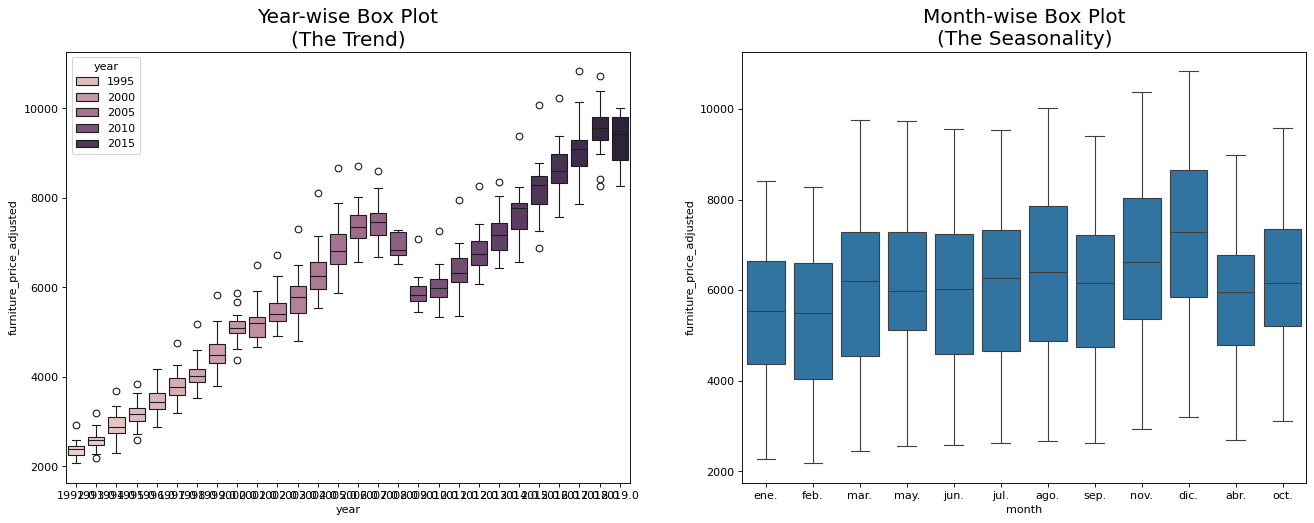

In [31]:
# 2. Visualizamos sus estadísticos
import seaborn as sns

# Prepare data
df_data['year'] = pd.to_datetime(df_data['Month']).dt.year
df_data['month'] = pd.to_datetime(df_data['Month']).dt.strftime('%b')
years = df_data['year'].unique()

# Draw Plot
fig, axes = plt.subplots(1, 2, figsize=(20,7), dpi= 80)
sns.boxplot(x='year', y='furniture_price_adjusted', data=df_data, ax=axes[0], hue='year')
sns.boxplot(x='month', y='furniture_price_adjusted', data=df_data.loc[~df_data.year.isin([1992, 2019]), :])

# Set Title
axes[0].set_title('Year-wise Box Plot\n(The Trend)', fontsize=18); 
axes[1].set_title('Month-wise Box Plot\n(The Seasonality)', fontsize=18)
plt.show()

In [ ]:
# Su media y su mediana varían a lo largo de la serie.
# O dividir la serie en 2 o 3 trozos y se calcula su media y varianza. Si no es estable ya no es estacionaria

## 6. ¿Conoces algún método para representar mejor la tendencia?

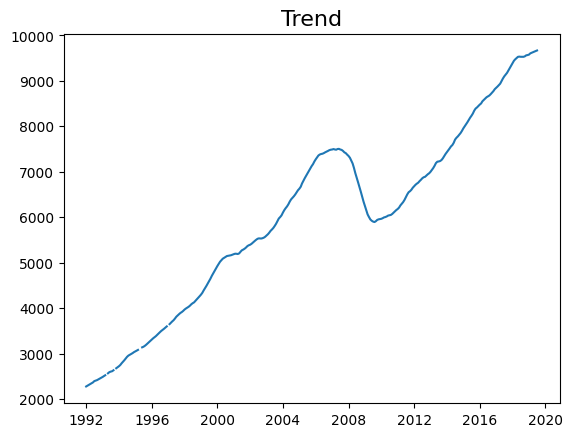

In [ ]:
# Code
# Podemos descomponer la serie temporal, por ejemplo el modelo aditivo y visualizar la tendencia
# También podría hacerse con una media móvil
from statsmodels.tsa.seasonal import seasonal_decompose

result = seasonal_decompose(df_data['furniture_price_adjusted'], model='additive', period = 12, extrapolate_trend='freq')
plt.plot(result.trend)
plt.title('Trend', fontsize=16);


## 7. Estaría bien visualizar todos los componentes de la serie temporal por separado

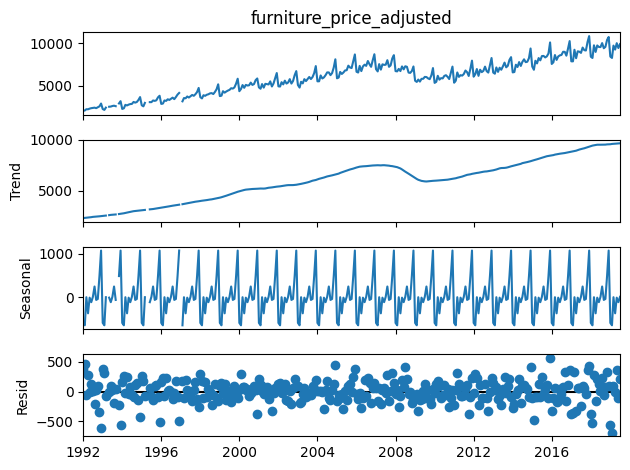

In [44]:
# Code
# visualizar todo

result.plot()
plt.show()

## 8. Demuestra mediante una gráfica de autocorrelación que la serie es estacional

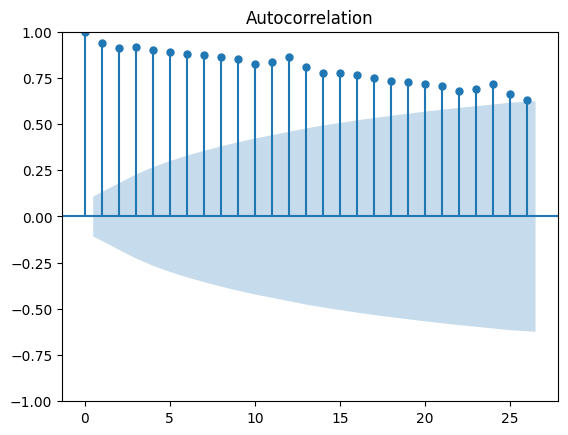

In [45]:
# Code
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df_data ['furniture_price_adjusted'].values);


In [ ]:
# La autocorrelación tiene un pico en el mes 12

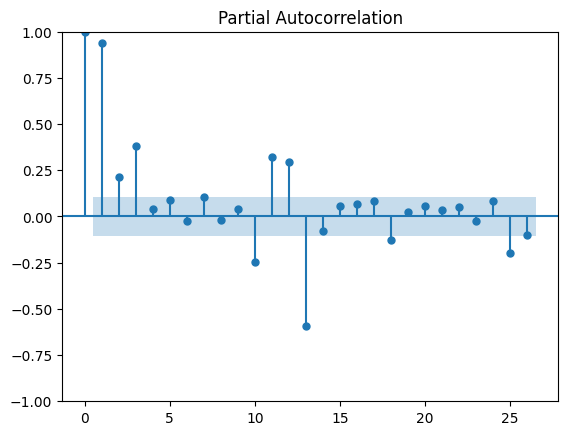

In [6]:

from statsmodels.graphics.tsaplots import plot_pacf
plot_pacf(df_data ['furniture_price_adjusted'].values);

Fuerte correlación parcial negativa en 13 meses. Hace lo contrario
Mide cada punto con todos los anteriores

## 9. ¿Qué dependencia tiene cada instante de sus últimos 5 lags? Demuéstralo mediante una matriz de correlación.

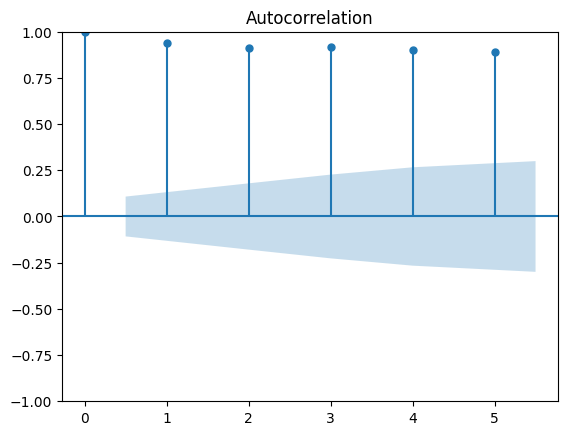

In [ ]:
# Code
# Falta la matriz de correlación.
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df_data['furniture_price_adjusted'], lags=5)
plt.show()

## 10. Ya hemos visto que hay estacionalidad. ¿Cada cuántos instantes se cumple ese patrón?

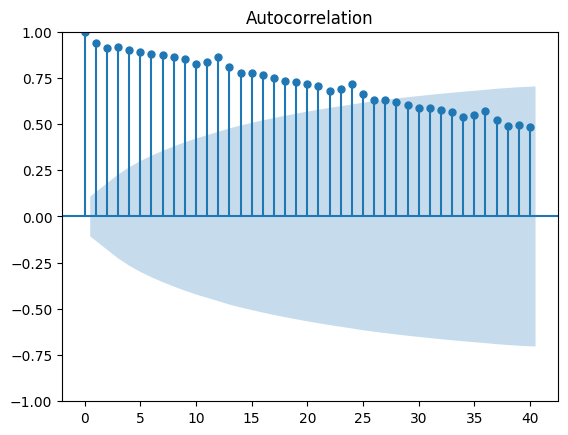

In [47]:
# Code
#De las gráficas previas ya se ha visto que cada 12. Vemos si ampliamos a más lags la gráfica que los picos
# están en los lags 12, 24 y 36
from statsmodels.graphics.tsaplots import plot_acf
plot_acf(df_data['furniture_price_adjusted'], lags=40)
plt.show()

## 11. Para un futuro modelado de los datos necesitaremos eliminar la tendencia. ¿Cómo hacemos esto?

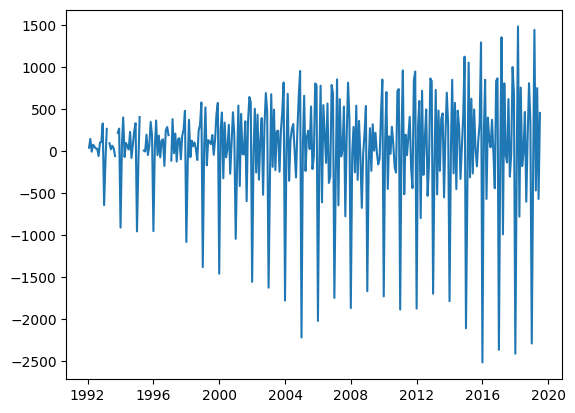

In [49]:
# Code
#Hay varias formas pero por ejemplo puede ser por diferenciacion
plt.plot(df_data['furniture_price_adjusted'].diff())

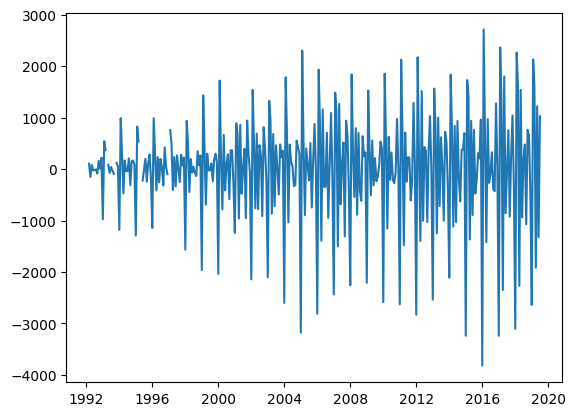

In [50]:
# igual queda un poco... puede volverse a aplicar diferenciación
plt.plot(df_data['furniture_price_adjusted'].diff().diff())

In [ ]:
# Otras dos opciones podían haber sido restarle la media móvil o seasonal decompose 